# Analyzing U.S. Job Market Trends Using Real Job Postings (2024–2025)

## Project Objective

This project explores a dataset of over 900 real job postings collected between January 2024 and April 2025.  
Our goal is to extract meaningful hiring insights that can help:

- Job seekers understand which roles, skills, and locations are in demand
- Recruiters and HR teams align hiring strategies with market trends
- Data analysts and business professionals monitor economic activity through employment patterns

## What Makes This Project Valuable

Rather than building a generic dashboard, we aim to combine time-based hiring trends with deeper insights derived from the job descriptions and company information.

We will explore:

- Monthly job posting trends and seasonality
- Top hiring regions and cities across the United States
- Most common job titles and their associated seniority levels
- Patterns in company hiring behavior
- Bonus: How the length of job descriptions varies by seniority or company type

We will present our findings using clear visualizations and concise written insights to make the project accessible to both technical and non-technical audiences.

This notebook demonstrates skills in data cleaning, exploratory data analysis (EDA), visualization, and insight storytelling.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/thousand-ml-jobs-in-usa/1000_ml_jobs_us.csv


## Step 1: Load the Dataset and Preview the Structure

Now that we've listed all input files, we’ll load the job postings dataset into a pandas DataFrame so we can begin our analysis.

In this step, we will:
- Read the CSV file using `pd.read_csv()`
- Check the shape of the dataset to understand how many rows and columns it contains
- Display the first 5 rows to understand the structure and values


In [2]:
# Load the dataset (update the filename below if needed based on your file list above)
df = pd.read_csv('/kaggle/input/thousand-ml-jobs-in-usa/1000_ml_jobs_us.csv')

# Check the shape (rows, columns)
print("Dataset contains", df.shape[0], "rows and", df.shape[1], "columns.")

# Display the first 5 rows of the dataset
df.head()


Dataset contains 997 rows and 10 columns.


,Unnamed: 0,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title
0,0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...
1,1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer
2,2,2025-04-09,San Jose,CA,Adobe,http://www.adobe.com,Adobe is the global leader in digital media an...,Our CompanyChanging the world through digital ...,Entry level,Machine Learning Engineer
3,3,2025-03-22,Mountain View,California,Waymo,https://waymo.com/careers/,On the journey to be the world's most trusted ...,Waymo is an autonomous driving technology comp...,Entry level,"Machine Learning Engineer, Training"
4,4,2025-03-28,Boston,Massachusetts,HMH,http://www.hmhco.com,We are an adaptive learning company that empow...,Job Title: Machine Learning EngineerLocation: ...,Mid-Senior level,Machine Learning Engineer


## Step 2: Inspect the Dataset – Structure, Missing Values, and Cleanup

Before we analyze trends, we need to understand:
- What data types each column has
- Whether there are missing or inconsistent values
- If there are columns we don’t need (like default indexes)

This helps ensure the dataset is clean and ready for analysis.


In [3]:
# Show a quick summary of the dataset including data types and non-null counts
df.info()

# Check for missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Preview the first few rows again to inspect 'Unnamed: 0'
df.head(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                997 non-null    int64 
 1   job_posted_date           997 non-null    object
 2   company_address_locality  950 non-null    object
 3   company_address_region    884 non-null    object
 4   company_name              997 non-null    object
 5   company_website           983 non-null    object
 6   company_description       985 non-null    object
 7   job_description_text      996 non-null    object
 8   seniority_level           988 non-null    object
 9   job_title                 997 non-null    object
dtypes: int64(1), object(9)
memory usage: 78.0+ KB

Missing values per column:
Unnamed: 0                    0
job_posted_date               0
company_address_locality     47
company_address_region      113
company_name                  0
company_

,Unnamed: 0,job_posted_date,company_address_locality,company_address_region,company_name,company_website,company_description,job_description_text,seniority_level,job_title
0,0,2024-10-31,Indianapolis,Indiana,Upper Hand,https://upperhand.com,Upper Hand is the leading provider of full-sui...,OverviewUpper Hand is embarking on an exciting...,Internship,Internship - Machine Learning Engineer & Data ...
1,1,2025-03-14,San Francisco,California,Ikigai,https://www.ikigailabs.io,"Built upon years of MIT research, Ikigai is a ...",Company DescriptionThe Ikigai platform unlocks...,Mid-Senior level,Machine Learning Engineer


## Step 3: Clean and Prepare the Dataset

In this step, we clean the dataset by:
- Removing the `Unnamed: 0` column, which is a leftover index
- Converting `job_posted_date` from string format to datetime format

This will help us later when analyzing trends over time.


In [4]:
# Drop the Unnamed: 0 column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert job_posted_date to datetime format
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Confirm changes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   job_posted_date           997 non-null    datetime64[ns]
 1   company_address_locality  950 non-null    object        
 2   company_address_region    884 non-null    object        
 3   company_name              997 non-null    object        
 4   company_website           983 non-null    object        
 5   company_description       985 non-null    object        
 6   job_description_text      996 non-null    object        
 7   seniority_level           988 non-null    object        
 8   job_title                 997 non-null    object        
dtypes: datetime64[ns](1), object(8)
memory usage: 70.2+ KB


## Step 4: Job Postings Over Time

Let’s explore how the number of job postings has changed over time.

We’ll:
- Group the job postings by month
- Count how many postings occurred in each month
- Visualize the results with a line chart

This gives us a clear view of hiring activity trends over the 2024–2025 period.


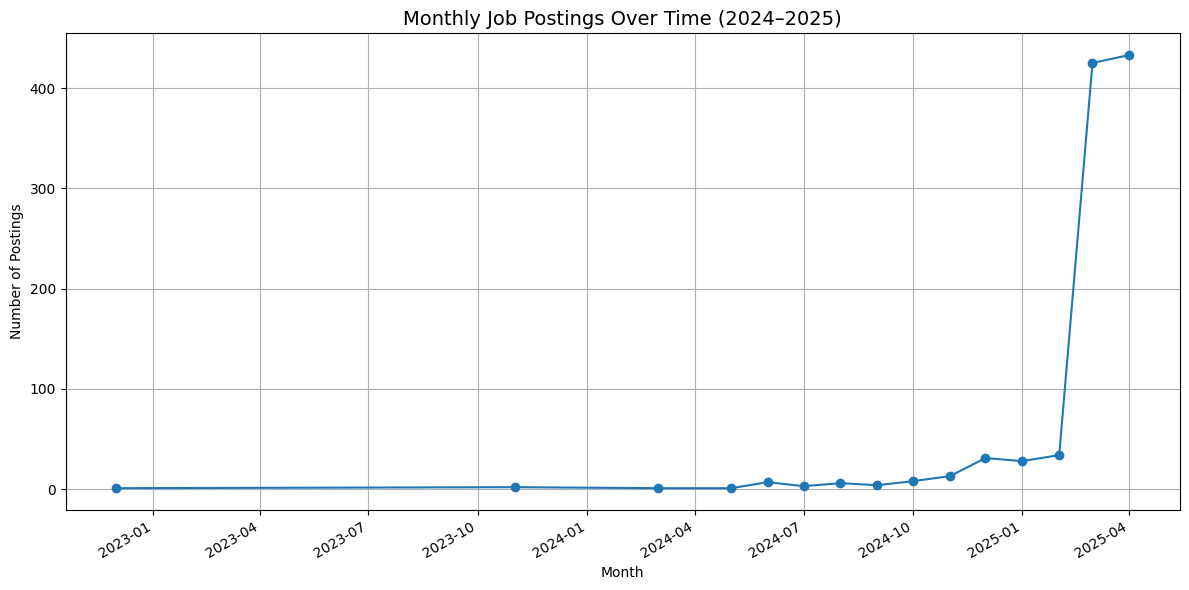

In [5]:
import matplotlib.pyplot as plt

# Group by month and count the number of postings
monthly_postings = df['job_posted_date'].dt.to_period('M').value_counts().sort_index()

# Convert PeriodIndex to datetime for plotting
monthly_postings.index = monthly_postings.index.to_timestamp()

# Plot the results
plt.figure(figsize=(12, 6))
monthly_postings.plot(kind='line', marker='o')
plt.title("Monthly Job Postings Over Time (2024–2025)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Postings")
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 5: Top Hiring Locations (Cities and States)

Let’s explore which U.S. cities and states had the most job postings.

We will:
- Count the number of job postings per city and region
- Visualize the top 10 most active locations using bar charts

This helps us identify geographic trends in hiring activity.


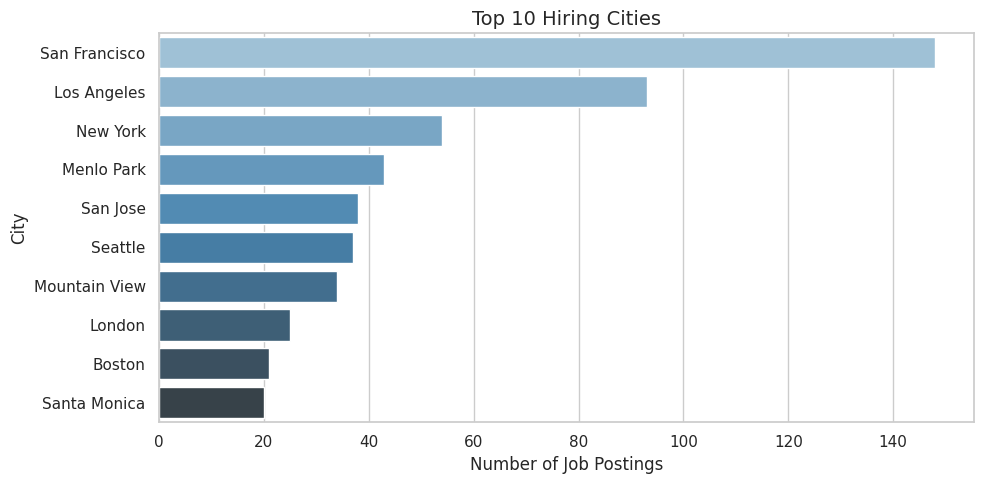

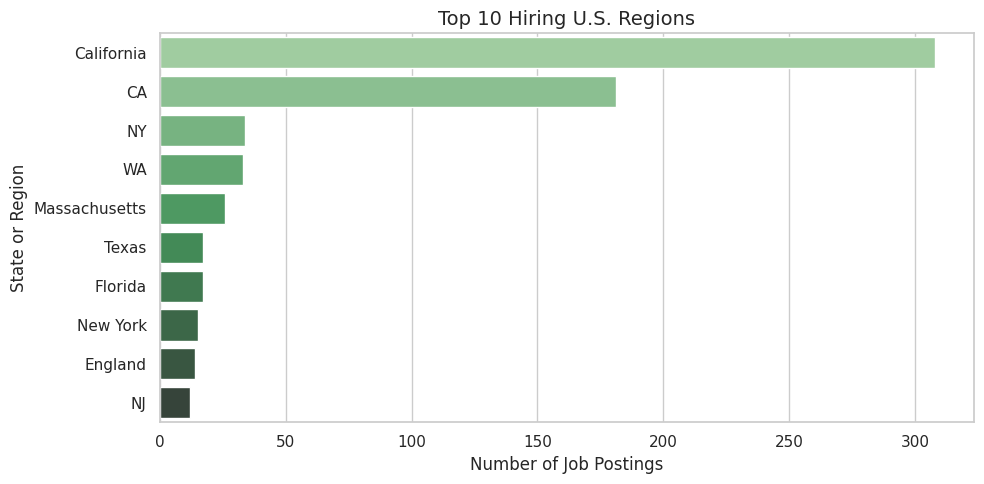

In [6]:
import seaborn as sns

# Set the visual style
sns.set(style="whitegrid")

# -----------------------------
# Top 10 Cities
# -----------------------------
top_cities = df['company_address_locality'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_d")
plt.title("Top 10 Hiring Cities", fontsize=14)
plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# -----------------------------
# Top 10 Regions/States
# -----------------------------
top_states = df['company_address_region'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.values, y=top_states.index, palette="Greens_d")
plt.title("Top 10 Hiring U.S. Regions", fontsize=14)
plt.xlabel("Number of Job Postings")
plt.ylabel("State or Region")
plt.tight_layout()
plt.show()


## Step 7: Analyzing Job Description Length

Here we explore how long job descriptions are, and whether the length varies by seniority level.

Longer descriptions may reflect:
- More responsibilities
- Higher role complexity
- More formal/structured hiring

We will:
- Calculate the word count for each job description
- Visualize the overall distribution
- Compare average length across seniority levels


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


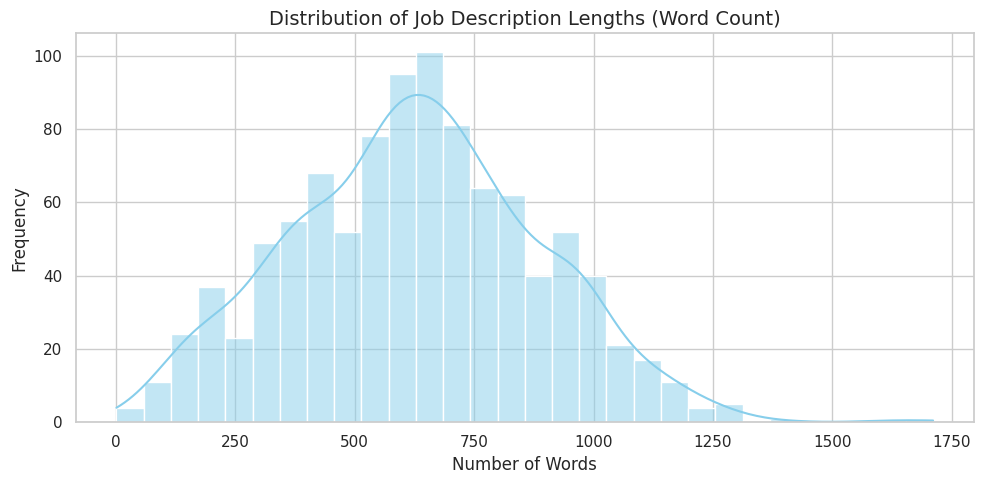

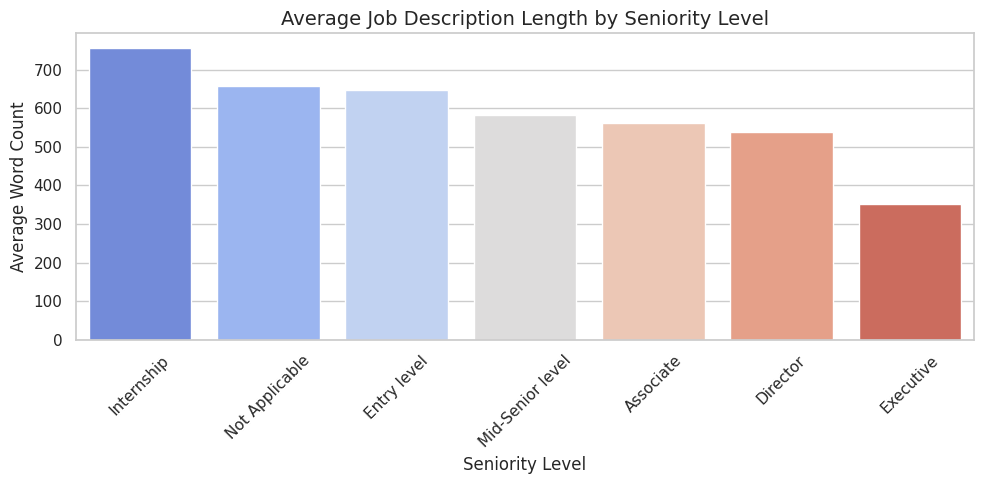

In [7]:
# Create a new column for job description word count
df['description_word_count'] = df['job_description_text'].apply(lambda x: len(str(x).split()))

# -----------------------------
# Distribution of Description Length
# -----------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df['description_word_count'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Job Description Lengths (Word Count)", fontsize=14)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# Average Description Length by Seniority
# -----------------------------
avg_length_by_seniority = df.groupby('seniority_level')['description_word_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_length_by_seniority.index, y=avg_length_by_seniority.values, palette="coolwarm")
plt.title("Average Job Description Length by Seniority Level", fontsize=14)
plt.xlabel("Seniority Level")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 8: Top Hiring Companies

Now let’s look at which companies posted the most job listings.

This helps us understand:
- Which companies are most active in hiring
- Whether hiring is dominated by a few large players or more evenly distributed

We will:
- Count job postings by company name
- Visualize the top 10 hiring companies


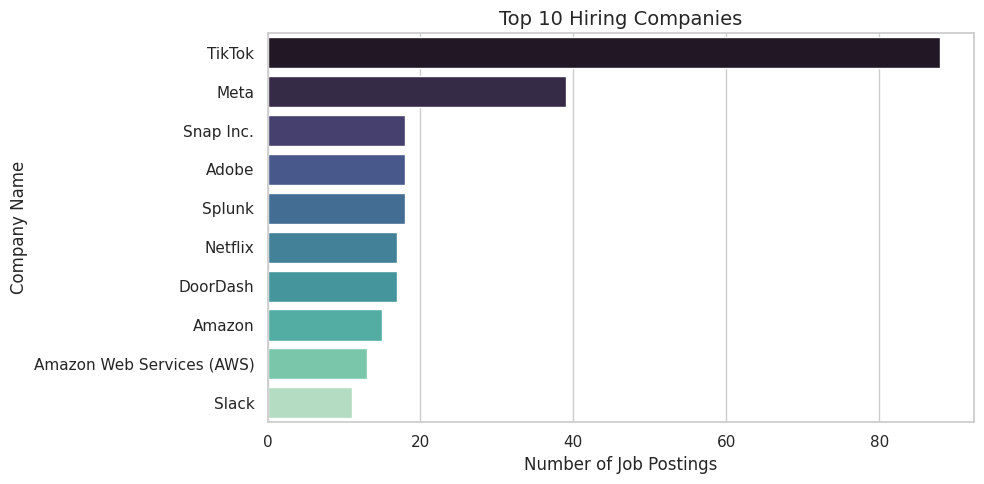

In [8]:
# Top 10 companies by number of job postings
top_companies = df['company_name'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_companies.values, y=top_companies.index, palette="mako")
plt.title("Top 10 Hiring Companies", fontsize=14)
plt.xlabel("Number of Job Postings")
plt.ylabel("Company Name")
plt.tight_layout()
plt.show()


## Step 9: Seniority Trends Over Time

Let’s examine whether companies are hiring more entry-level, mid-senior, or internship roles over time.

This adds a time dimension to the seniority analysis and helps us understand how hiring focus shifts by quarter.


<Figure size 1200x600 with 0 Axes>

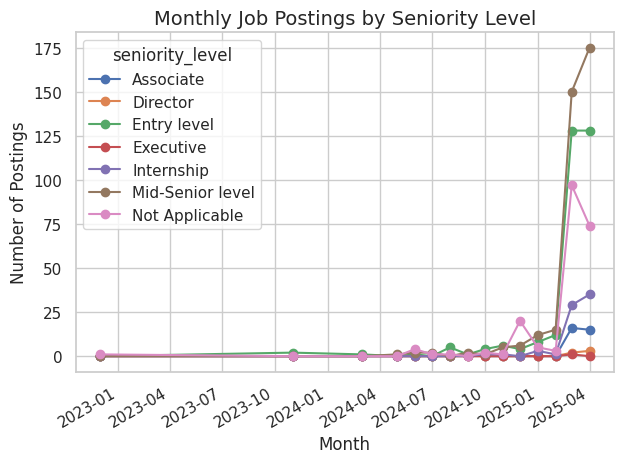

In [9]:
# Extract month from date
df['year_month'] = df['job_posted_date'].dt.to_period('M')

# Count seniority per month
seniority_trend = df.groupby(['year_month', 'seniority_level']).size().unstack().fillna(0)

# Convert PeriodIndex to timestamp
seniority_trend.index = seniority_trend.index.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
seniority_trend.plot(kind='line', marker='o')
plt.title("Monthly Job Postings by Seniority Level", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Postings")
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 10: Most Common Words by Seniority Level

Using NLP, we extract the most frequent words from job descriptions for different seniority levels.

This gives a sense of what skills, expectations, or themes appear more frequently in senior vs. junior jobs.


In [10]:
from collections import Counter
import re

# Preprocessing function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Function to get top N words from job descriptions per seniority level
def get_top_words(level, n=15):
    text = df[df['seniority_level'] == level]['job_description_text'].dropna().apply(clean_text)
    all_words = ' '.join(text).split()
    return Counter(all_words).most_common(n)

# Get words for each level
levels = df['seniority_level'].dropna().unique()
top_words_by_level = {level: get_top_words(level) for level in levels}

# Display as DataFrame
pd.DataFrame({k: dict(v) for k, v in top_words_by_level.items()})


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Internship,Mid-Senior level,Entry level,Not Applicable,Associate,Executive,Director
and,2875.0,12025.0,10942.0,7542.0,1054.0,22.0,159.0
to,1792.0,6557.0,6026.0,3841.0,581.0,7.0,91.0
the,1451.0,5214.0,5039.0,3438.0,426.0,NaN,60.0
in,986.0,3921.0,3334.0,2477.0,299.0,NaN,51.0
of,968.0,4203.0,3750.0,2893.0,338.0,12.0,44.0
for,786.0,2985.0,2789.0,1786.0,225.0,NaN,44.0
a,781.0,3629.0,3120.0,2192.0,306.0,7.0,53.0
with,667.0,3517.0,2935.0,2116.0,329.0,5.0,40.0
our,585.0,1980.0,2048.0,1371.0,136.0,NaN,18.0
is,579.0,1798.0,1883.0,1110.0,140.0,NaN,25.0


## Step 11: Job Title Clustering (Text Embedding + KMeans)

We vectorize job titles using TF-IDF or sentence embeddings and then use clustering to discover similar groups of roles (e.g., all AI roles, all marketing roles).

This shows NLP + unsupervised learning + visualization.


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Clean job titles
titles = df['job_title'].dropna().unique()

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(titles)

# KMeans clustering
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# Combine into a DataFrame for display
clustered_titles = pd.DataFrame({'Job Title': titles, 'Cluster': labels})
clustered_titles.sort_values(by='Cluster').head(15)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,Job Title,Cluster
0,Internship - Machine Learning Engineer & Data ...,0
198,Senior Machine Learning Engineer I,0
204,"(General Hire) Machine Learning Engineer, TikT...",0
206,Machine Learning Engineer in the Optimization ...,0
207,Machine Learning Engineer (Remote Position),0
209,"Machine Learning Engineer, TikTok Branding Ads",0
215,Machine Learning Engineer - New Verticals Catalog,0
218,Machine Learning Model Engineer - Advertising ...,0
219,"Machine Learning Engineer, Fine-Tuning API",0
448,"Machine Learning Engineer, Tapestry",0


## Step 12: Average Job Description Length by Company

We analyze the average word count of job descriptions by company to find which firms write more detailed postings.


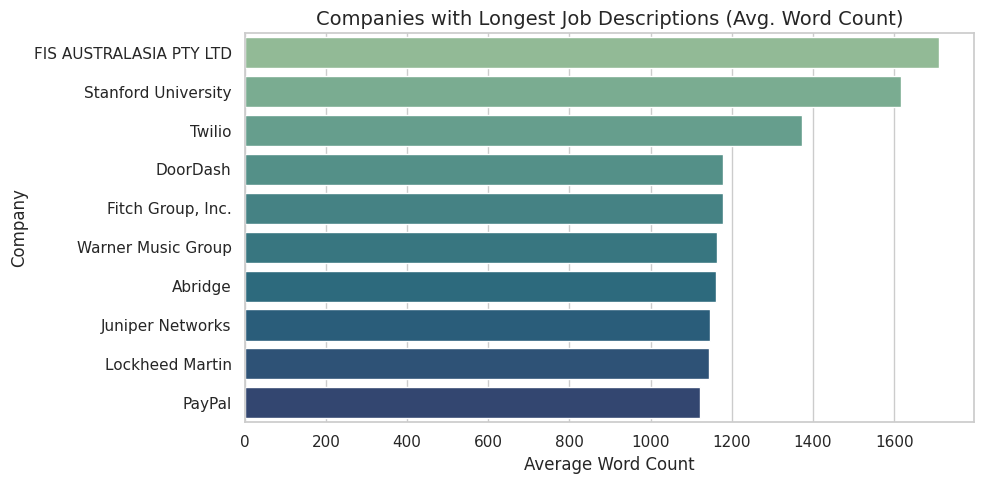

In [12]:
company_length = df.groupby('company_name')['description_word_count'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=company_length.values, y=company_length.index, palette='crest')
plt.title("Companies with Longest Job Descriptions (Avg. Word Count)", fontsize=14)
plt.xlabel("Average Word Count")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


## Step 13: Job Title Clustering with TF-IDF and KMeans

Job titles often differ in wording even when they mean similar things. In this step, we apply unsupervised machine learning to group similar job titles.

We will:
- Vectorize job titles using TF-IDF
- Cluster them using KMeans
- View the top job titles per cluster

This step shows how NLP and unsupervised learning can organize messy, real-world job titles into structured insights.


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Drop NaNs
titles = df['job_title'].dropna().unique()

# TF-IDF Vectorizer for job titles
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(titles)

# KMeans clustering
k = 6  # Number of clusters (can try different values)
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# Store results in DataFrame
clustered_titles = pd.DataFrame({'Job Title': titles, 'Cluster': labels})
clustered_titles.sort_values(by='Cluster').head(15)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,Job Title,Cluster
0,Internship - Machine Learning Engineer & Data ...,0
204,"(General Hire) Machine Learning Engineer, TikT...",0
206,Machine Learning Engineer in the Optimization ...,0
207,Machine Learning Engineer (Remote Position),0
209,"Machine Learning Engineer, TikTok Branding Ads",0
215,Machine Learning Engineer - New Verticals Catalog,0
218,Machine Learning Model Engineer - Advertising ...,0
219,"Machine Learning Engineer, Fine-Tuning API",0
448,"Machine Learning Engineer, Tapestry",0
225,Machine Learning Research Scientist / Machine ...,0
